# 프로세스 흐름도

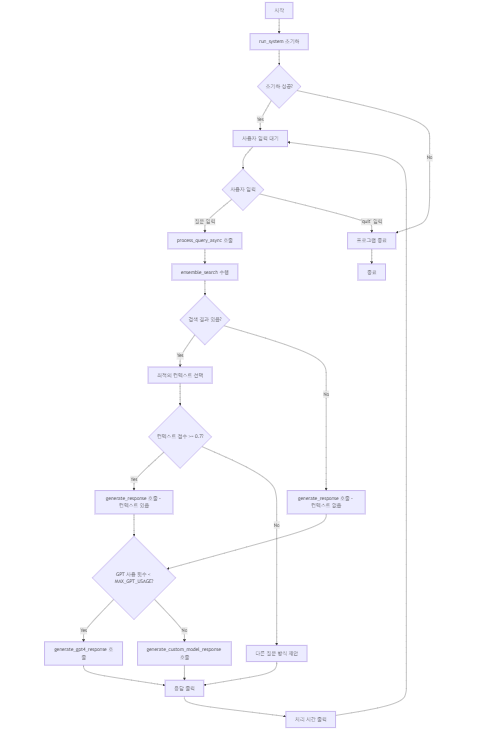

# 전체 코드

## 라이브러리 설치 및 임포트

In [1]:
# 필요한 라이브러리 설치
!pip install torch torchvision torchaudio transformers sentence-transformers qdrant-client langchain langchain-community langchain-openai openai scikit-learn rank_bm25 tiktoken numpy tqdm langchain-qdrant nest-asyncio


In [2]:
# 필요한 라이브러리 임포트
import os
import asyncio
import logging
import time
import datetime
from typing import List, Dict, Any, Optional, Tuple

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from langchain.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Qdrant as LangchainQdrant
from langchain.schema import Document
from langchain.retrievers import BM25Retriever
from openai import AsyncOpenAI
import nest_asyncio
from google.colab import userdata

## 기본 설정 및 초기화

In [3]:
# 설정
QDRANT_URL = "https://6e46b2c2-f28a-4f28-854d-432ab699fdfd.europe-west3-0.gcp.cloud.qdrant.io"
QDRANT_API_KEY = "u2eejPgTwIyhr7BVjFBtkjGdGYPWvzQTBkoYycErtm5cyrFjwEEH9w"
COLLECTION_NAME = "son99_d"
MODEL_NAME = "centwon/ko-gpt-trinity-1.2B-v0.5_v3"
MAX_GPT_USAGE = 1  # GPT-4 사용 횟수 제한

# 초기화
nest_asyncio.apply()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
openai_api_key = userdata.get('FINAL_TEAM3')
client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
embeddings = HuggingFaceEmbeddings(model_name="jhgan/ko-sroberta-multitask")
vector_store = LangchainQdrant(client=client, collection_name=COLLECTION_NAME, embeddings=embeddings)
st_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
openai_client = AsyncOpenAI(api_key=openai_api_key)

# 전역 변수
gpt_usage_count = 0
last_reset_date = datetime.date.today()

# 전역 변수로 모델과 토크나이저 선언
custom_model = None
custom_tokenizer = None

/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:151: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 0.3.0. An updated version of the class exists in the langchain-huggingface package and should be used instead. To use it run `pip install -U langchain-huggingface` and import as `from langchain_huggingface import HuggingFaceEmbeddings`.
  warn_deprecated(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10

## QdrantRetriever

In [4]:
class QdrantRetriever:
    def __init__(self, client: QdrantClient, collection_name: str):
        self.client = client
        self.collection_name = collection_name

    def retrieve(self, query_vector: List[float], top_k: int = 20) -> List[Any]:
        return self.client.search(collection_name=self.collection_name, query_vector=query_vector, limit=top_k)


## Qdrant 검색 결과 ->  Langchain의 Document 객체 리스트로 변환

In [5]:
def create_documents_from_qdrant_results(results) -> List[Document]:
    return [Document(
        page_content=result.payload.get('답변', 'N/A'),
        metadata={
            'id': result.id,
            '질병 카테고리': result.payload.get('질병_카테고리', 'N/A'),
            '질병': result.payload.get('질병', 'N/A'),
            '부서': result.payload.get('부서', 'N/A'),
            '의도': result.payload.get('의도', 'N/A'),
            'score': result.score
        }
    ) for result in results]

## ensemble model

In [6]:
async def ensemble_search(query: str, top_k: int = 5) -> List[Document]:
    encoder = SentenceTransformer("jhgan/ko-sroberta-multitask")
    qdrant_retriever = QdrantRetriever(client=client, collection_name="son99_d")

    query_vector = encoder.encode(query).tolist()
    qdrant_results = qdrant_retriever.retrieve(query_vector, top_k=20)

    if not qdrant_results:
        logging.warning("Qdrant에서 검색 결과가 없습니다.")
        return []

    documents = create_documents_from_qdrant_results(qdrant_results)
    bm25_retriever = BM25Retriever.from_documents(documents)
    bm25_results = bm25_retriever.get_relevant_documents(query)

    if not bm25_results:
        logging.warning("BM25에서 유사한 문서가 없습니다.")
        return documents[:top_k]

    combined_results = []
    for bm25_result in bm25_results:
        matching_qdrant_result = next((doc for doc in documents if doc.page_content == bm25_result.page_content), None)
        if matching_qdrant_result:
            combined_score = 0.5 * matching_qdrant_result.metadata.get('score', 0) + 0.5 * bm25_result.metadata.get('score', 1)
            matching_qdrant_result.metadata['combined_score'] = combined_score
            combined_results.append(matching_qdrant_result)

    if not combined_results:
        logging.warning("결합된 결과가 없습니다.")
        return documents[:top_k]

    combined_results.sort(key=lambda x: x.metadata['combined_score'], reverse=True)
    return [result for result in combined_results[:top_k] if result.page_content and result.page_content.strip()]


## GPT 모델 사용량 체크

In [7]:
def check_and_reset_gpt_usage():
    global gpt_usage_count, last_reset_date
    today = datetime.date.today()
    if today > last_reset_date:
        gpt_usage_count = 0
        last_reset_date = today

## GPT4o-turbo model

In [8]:
async def generate_gpt4_response(query: str, context: Optional[str] = None, metadata: Optional[Dict[str, str]] = None) -> str:
    try:
        system_message = (
            "You are an expert medical assistant designed to support seniors during medical emergencies "
            "while traveling. Your primary role is to provide accurate and clear medical advice based on the user's "
            "symptoms or questions about diseases. When the user asks about a disease or symptom, "
            "show the related metadata, such as the disease and intent, and then provide the best advice based on "
            "the retrieved information. Please respond in Korean and provide a complete response."
            "Generating an answer, please make it within max_tokens."
        )

        user_message = f"User Query: {query}\n\nContext: {context}\n\nMetadata: {metadata}"

        response = await openai_client.chat.completions.create(
            model="gpt-4-turbo-preview",
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_message}
            ],
            max_tokens=1000,
            temperature=0.3,
            n=1,
            stop=None,
        )

        generated_response = response.choices[0].message.content.strip()
        logging.info(f"GPT-4 응답 생성 완료: 길이={len(generated_response)}")
        return generated_response

    except Exception as e:
        logging.error(f"GPT-4 응답 생성 중 오류 발생: {str(e)}", exc_info=True)
        return "죄송합니다. GPT-4 응답을 생성하는 중에 오류가 발생했습니다."


## ko-gpt-trinity-1.2B-v0.5_v2
 - 우리가 파인 튜닝한 모델 v2

In [9]:
async def generate_custom_model_response(query: str, context: Optional[str] = None, metadata: Optional[Dict[str, str]] = None) -> str:
    try:
        prompt = f"""질문: {query}
컨텍스트: {context or ''}
메타데이터: {metadata or {}}

위 정보를 바탕으로 질문에 대한 간결하고 정확한 답변을 제공해주세요. 답변은 다음 형식을 따라주세요:
1. 질문과 직접적으로 관련된 핵심 정보를 먼저 제시합니다.
2. 필요한 경우 추가 설명이나 예시를 제공합니다.
3. 의학적 조언이 필요한 경우, 전문의 상담을 권장합니다.

답변:"""

        inputs = custom_tokenizer(prompt, return_tensors="pt", max_length=512, truncation=True).to(custom_model.device)
        with torch.no_grad():
            outputs = custom_model.generate(
                **inputs,
                max_length=600,  # 답변 길이 제한 감소
                num_return_sequences=1,
                no_repeat_ngram_size=3,
                temperature=0.7,
                do_sample=True,  # 확률적 샘플링 활성화
                top_k=50,
                top_p=0.95,
            )

        response = custom_tokenizer.decode(outputs[0], skip_special_tokens=True)
        response = response.split("답변:")[-1].strip()

        # 간소화된 후처리
        sentences = response.split('.')[:3]  # 최대 3문장으로 제한
        response = '. '.join(s.strip() for s in sentences if s.strip())

        return response

    except Exception as e:
        logging.error(f"커스텀 모델 응답 생성 중 오류 발생: {str(e)}", exc_info=True)
        return "죄송합니다. 응답을 생성하는 중에 오류가 발생했습니다."


## model 응답 생성 관리

In [10]:
async def generate_response(query: str, context: Optional[str] = None, metadata: Optional[Dict[str, str]] = None) -> Tuple[str, str]:
    global gpt_usage_count

    try:
        if gpt_usage_count < MAX_GPT_USAGE:
            gpt_usage_count += 1
            response = await generate_gpt4_response(query, context, metadata)
            return response, "GPT-4"
        else:
            response = await generate_custom_model_response(query, context, metadata)
            return response, "Custom Model"
    except Exception as e:
        logging.error(f"응답 생성 중 오류 발생: {str(e)}", exc_info=True)
        return "죄송합니다. 응답을 생성하는 중에 오류가 발생했습니다.", "Error"


## 사용자 쿼리 처리

In [11]:
async def process_query_async(query: str) -> Tuple[str, str, float]:
    start_time = time.time()
    logging.info(f"처리 중인 쿼리: {query}")

    try:
        ensemble_results = await ensemble_search(query, 5)

        if not ensemble_results:
            logging.warning("앙상블 검색 결과가 없습니다.")
            response, model = await generate_response(query)
            return response, model, time.time() - start_time

        best_match = ensemble_results[0]
        context = best_match.page_content
        metadata = best_match.metadata

        print(f"\nDB에서 검색된 정보:\n내용: {context}\n메타데이터: {metadata}\n")

        if metadata.get('combined_score', 0) < 0.7:
            logging.warning("질문과 관련된 정보를 찾기 어렵습니다. 다른 방식으로 질문해 주시겠어요?")
            return "질문과 관련된 정보를 찾기 어렵습니다. 다른 방식으로 질문해 주시겠어요?", "System Message", time.time() - start_time

        response, model = await generate_response(query, context, metadata)

        processing_time = time.time() - start_time
        logging.info(f"처리 시간: {processing_time:.2f}초")

        return response, model, processing_time

    except Exception as e:
        logging.error(f"쿼리 처리 중 오류 발생: {str(e)}", exc_info=True)
        response, model = await generate_response(query)
        return response, model, time.time() - start_time


In [12]:
async def run_system():
    print("의료 정보 시스템을 초기화하는 중...")

    try:
        client.get_collections()
        print("Qdrant 서버에 성공적으로 연결되었습니다.")

        global st_model, custom_model, custom_tokenizer
        st_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
        print("임베딩 모델이 로드되었습니다.")

        if not openai_api_key:
            raise ValueError("OpenAI API 키가 설정되지 않았습니다.")
        print("OpenAI API 키가 확인되었습니다.")

        # 커스텀 모델 초기화 (한 번만 수행)
        custom_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to('cuda' if torch.cuda.is_available() else 'cpu')
        custom_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        print("커스텀 모델과 토크나이저가 초기화되었습니다.")

        print("\n의료 정보 시스템이 성공적으로 초기화되었습니다.")
        print("시스템이 준비되었습니다. 질문을 입력해주세요.")

    except Exception as e:
        print(f"시스템 초기화 중 오류가 발생했습니다: {str(e)}")
        print("시스템을 종료합니다.")
        return False

    return True

## 성능 테스트

In [13]:
async def evaluate_system():
    test_queries = [
        "순환기 질환인 고혈압 증상이 궁금해요",
        "고혈압 치료방법이 궁금해요",
        "고혈압에 대해 알고 싶어요",
        "머리가 어지럽고 가슴통증이 있고 시야에 문제가 있고 코피가나",
        "아 어지러운데 이게뭐지"
    ]

    total_time = 0
    total_queries = len(test_queries)

    for query in test_queries:
        try:
            response, model, processing_time = await process_query_async(query)
            total_time += processing_time

            print(f"질문: {query}")
            print(f"답변 ({model}): {response}")
            print(f"처리 시간: {processing_time:.2f}초")
            print("-" * 50)

        except Exception as e:
            logging.error(f"쿼리 처리 중 오류 발생: {str(e)}")

    avg_time = total_time / total_queries if total_queries > 0 else 0
    print(f"평균 처리 시간: {avg_time:.2f}초")


## 실행

In [14]:
async def main():
    if not await run_system():
        return

    while True:
        user_query = input("질문을 입력하세요 (종료하려면 'quit' 입력): ")
        if user_query.lower() == 'quit':
            print("프로그램을 종료합니다.")
            break

        try:
            response, model, processing_time = await process_query_async(user_query)
            print(f"\n답변 ({model}):\n{response}")
            print(f"처리 시간: {processing_time:.2f}초\n")
        except Exception as e:
            print(f"오류 발생: {str(e)}")
            print("다시 질문해 주세요.")

if __name__ == "__main__":
    asyncio.run(main())

의료 정보 시스템을 초기화하는 중...
Qdrant 서버에 성공적으로 연결되었습니다.
임베딩 모델이 로드되었습니다.
OpenAI API 키가 확인되었습니다.
커스텀 모델과 토크나이저가 초기화되었습니다.

의료 정보 시스템이 성공적으로 초기화되었습니다.
시스템이 준비되었습니다. 질문을 입력해주세요.
질문을 입력하세요 (종료하려면 'quit' 입력): 고혈압 증상에 대해서 알려줘.


/usr/local/lib/python3.10/dist-packages/langchain_core/_api/deprecation.py:151: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use invoke instead.
  warn_deprecated(



DB에서 검색된 정보:
내용: 고혈압을 진단하기 위해서는 증상을 관찰하고, 전문의의 조언을 따라야 합니다. 만약 고혈압이 의심된다면, 혈압을 측정하기 위해 병원을 방문하거나 혈압계를 사용해야 합니다. 고혈압 환자는 정기적으로 혈압을 평가하고 변화를 주시해야 합니다.
메타데이터: {'id': 1814, '질병 카테고리': '순환기질환', '질병': '고혈압', '부서': '내과', '의도': '정의', 'score': 0.75768435, 'combined_score': 0.75768435}


답변 (GPT-4):
고혈압은 혈압이 비정상적으로 높은 상태를 말합니다. 고혈압의 증상은 다음과 같습니다:

1. 두통
2. 어지럼증
3. 가슴 통증
4. 호흡 곤란
5. 시야 흐림
6. 코피

하지만 많은 고혈압 환자들이 특별한 증상을 느끼지 않는 경우도 많습니다. 이러한 이유로 고혈압을 '침묵의 살인자'라고도 부릅니다. 정기적인 혈압 측정은 고혈압을 조기에 발견하고 관리하는 데 매우 중요합니다. 만약 위의 증상 중 하나 이상을 경험한다면, 혈압을 측정하고 내과 전문의와 상담하는 것이 좋습니다. 고혈압이 장기간 관리되지 않으면 심장병, 뇌졸중, 신장 문제와 같은 심각한 건강 문제를 초래할 수 있습니다.
처리 시간: 12.58초

질문을 입력하세요 (종료하려면 'quit' 입력): 고혈압 증상에 대해서 알려줘.

DB에서 검색된 정보:
내용: 고혈압을 진단하기 위해서는 증상을 관찰하고, 전문의의 조언을 따라야 합니다. 만약 고혈압이 의심된다면, 혈압을 측정하기 위해 병원을 방문하거나 혈압계를 사용해야 합니다. 고혈압 환자는 정기적으로 혈압을 평가하고 변화를 주시해야 합니다.
메타데이터: {'id': 1814, '질병 카테고리': '순환기질환', '질병': '고혈압', '부서': '내과', '의도': '정의', 'score': 0.75768435, 'combined_score': 0.75768435}


답변 (Custom Model):
혈압은 지속적으로 상승할 수 있으


DB에서 검색된 정보:
내용: 식중독 치료는 탈수를 예방하고, 감염원을 제거하는 것이 매우 중요합니다. 수분 보충을 위해 수액을 섭취하고, 식중독이 발생하면 항생제나 항진균제를 사용하여 원인균을 제거할 수 있습니다. 특히 세균성 식중독이 발생할 경우에는 항생제가 효과적입니다. 세균성 식중독은 주로 항생제를 복용하여 치료할 수 있으며, 예방을 위해 식중독 예방에 주의해야 합니다.
메타데이터: {'id': 13063, '질병 카테고리': '응급질환', '질병': '식중독', '부서': '내과', '의도': '치료', 'score': 0.6754321, 'combined_score': 0.6754321}


답변 (System Message):
질문과 관련된 정보를 찾기 어렵습니다. 다른 방식으로 질문해 주시겠어요?
처리 시간: 2.12초

질문을 입력하세요 (종료하려면 'quit' 입력): 고혈압 치료방법에 대해서 알려줘.

DB에서 검색된 정보:
내용: 고혈압은 생활습관 개선과 약물 치료로 효과적으로 치료될 수 있습니다. 약물 치료로는 고혈압 약이 사용되며, 일차적으로는 원인이 있는 고혈압을 치료하는 것이 가장 중요합니다. 고혈압 약물에는 칼슘채널차단제, ARB, 베타 차단제 등이 사용되며, 환자의 상태에 따라 선택되어 처방됩니다.
메타데이터: {'id': 5653, '질병 카테고리': '순환기질환', '질병': '고혈압', '부서': '내과', '의도': '치료', 'score': 0.74788153, 'combined_score': 0.74788153}


답변 (Custom Model):
고혈압 약물은 혈압을 조절하고 심혈관 건강을 개선하는 데 사용됩니다. 약물 치료는 혈압 강하와 혈류 개선을 통해 심혈관계 질환을 예방하고 합병증을 줄이는 데 도움을 줍니다. 약물 치료와 함께 생활습관의 변화가 필요합니다
처리 시간: 259.21초

질문을 입력하세요 (종료하려면 'quit' 입력): quit
프로그램을 종료합니다.


## 결과 :
 1. gpt는 여전히 잘 작동함
 2. v3는 답변이 잘 나오는 것도 아니고, 시간도 오래걸림